In [1]:
import matplotlib.pyplot
from numpy.ma.core import multiply


# Add line profiler
%load_ext line_profiler

#Import packages we need
from matplotlib import animation, rc
from matplotlib import pyplot as plt

#Lets have matplotlib "inline"
matplotlib.pyplot.ion()

#Set large figure sizes
#Note, this prevents nice figures for articles...
rc('figure', figsize=(16.0, 12.0))
rc('animation', html='html5')

import importlib

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

from GPUSimulators import IPythonMagic
from GPUSimulators.common import Timer
from GPUSimulators.helpers import InitialConditions

In [2]:
%setup_logging --out=test_schemes.log TestSchemes

Console logger using level INFO
File logger using level DEBUG to test_schemes.log
Python version 3.13.5 | packaged by conda-forge | (main, Jun 16 2025, 08:27:50) [GCC 13.3.0]


In [3]:
%cuda_context_handler my_context --no_autotuning

Registering my_context in user workspace
Using cache dir /home/smyalygames/Repositories/FiniteVolumeGPU/.fvm_cache/hipcontext
HIP Python version 6.4.43483-a187df25c
ROCm version 6.4.1
Using device 0/1 'AMD Radeon RX 6950 XT (gfx1030)' (3)


In [4]:
nx = 256
ny = 128
g = 9.81

h0, hu0, hv0, dx, dy = InitialConditions.bump(nx, ny, 100, 100, 15)

# print(my_context.autotuner.get)

arguments = {
    'context': my_context,
    'h0': h0, 'hu0': hu0, 'hv0': hv0,
    'nx': nx, 'ny': ny,
    'dx': dx, 'dy': dy, 
    'g': g,
    'compile_opts': []
}

t_end = 20

In [5]:
def plot(sim):
    h = sim.u0[0].download(sim.stream)
    
    plt.figure()
    plt.title(str(sim) + ", t=" + str(sim.sim_time()) + ", nt=" + str(sim.sim_steps()))
    extent = [0, sim.dx*sim.nx, 0, sim.dy*sim.ny]
    plt.imshow(h, vmin=0.49, vmax=0.52, extent=extent)
    plt.colorbar()

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

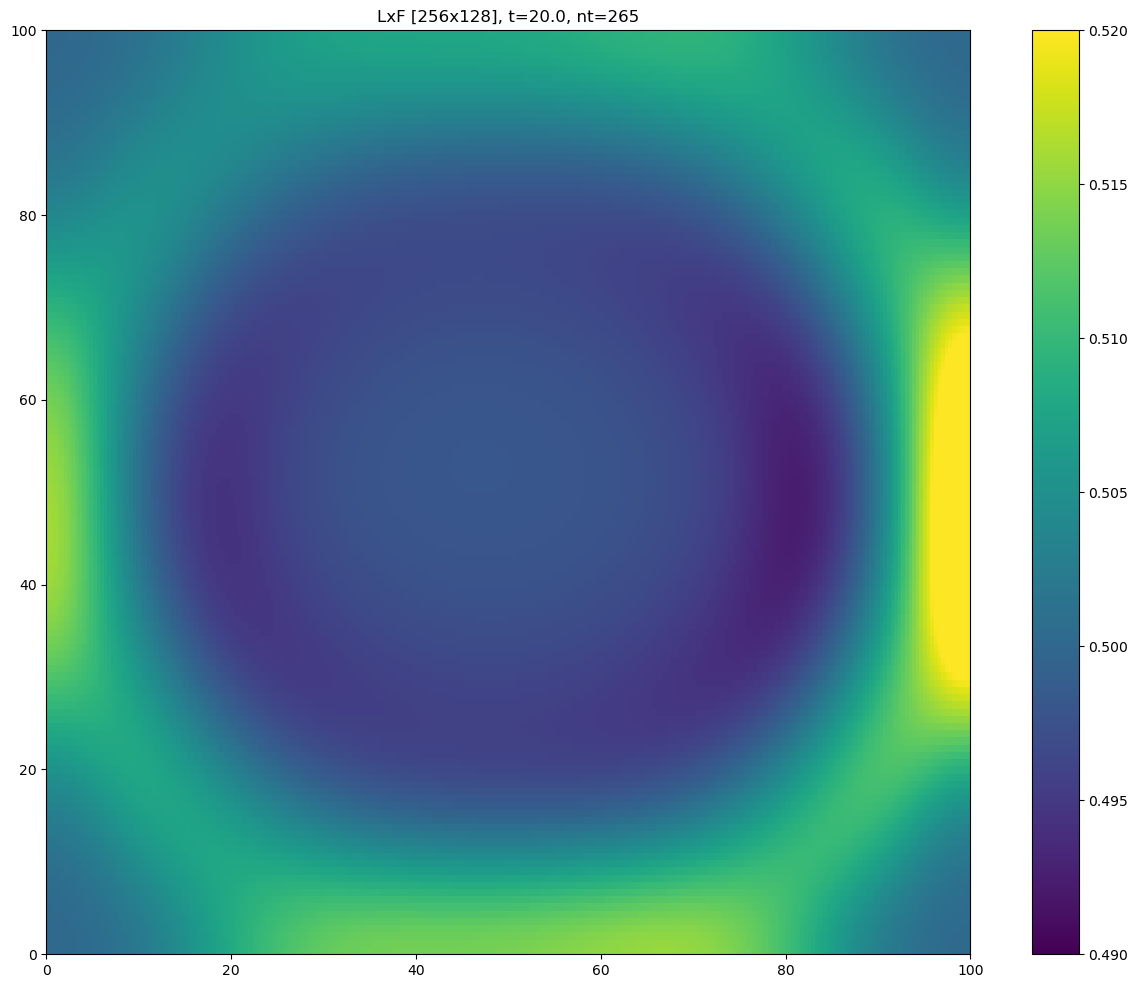

In [6]:
from GPUSimulators.model.lxf import LxF

with Timer("construct") as t:
    sim = LxF(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

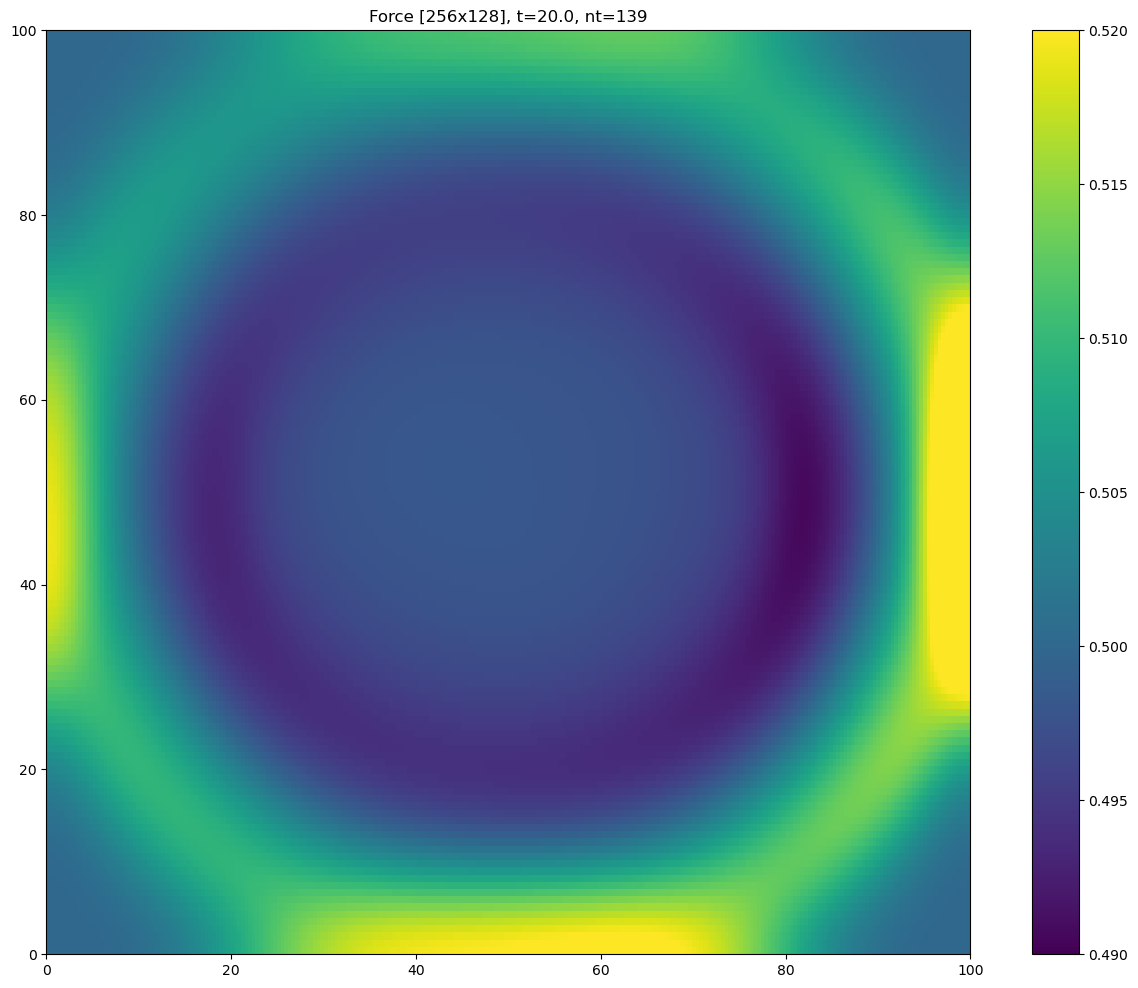

In [7]:
from GPUSimulators.model import Force

with Timer("construct") as t:
    sim = Force(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

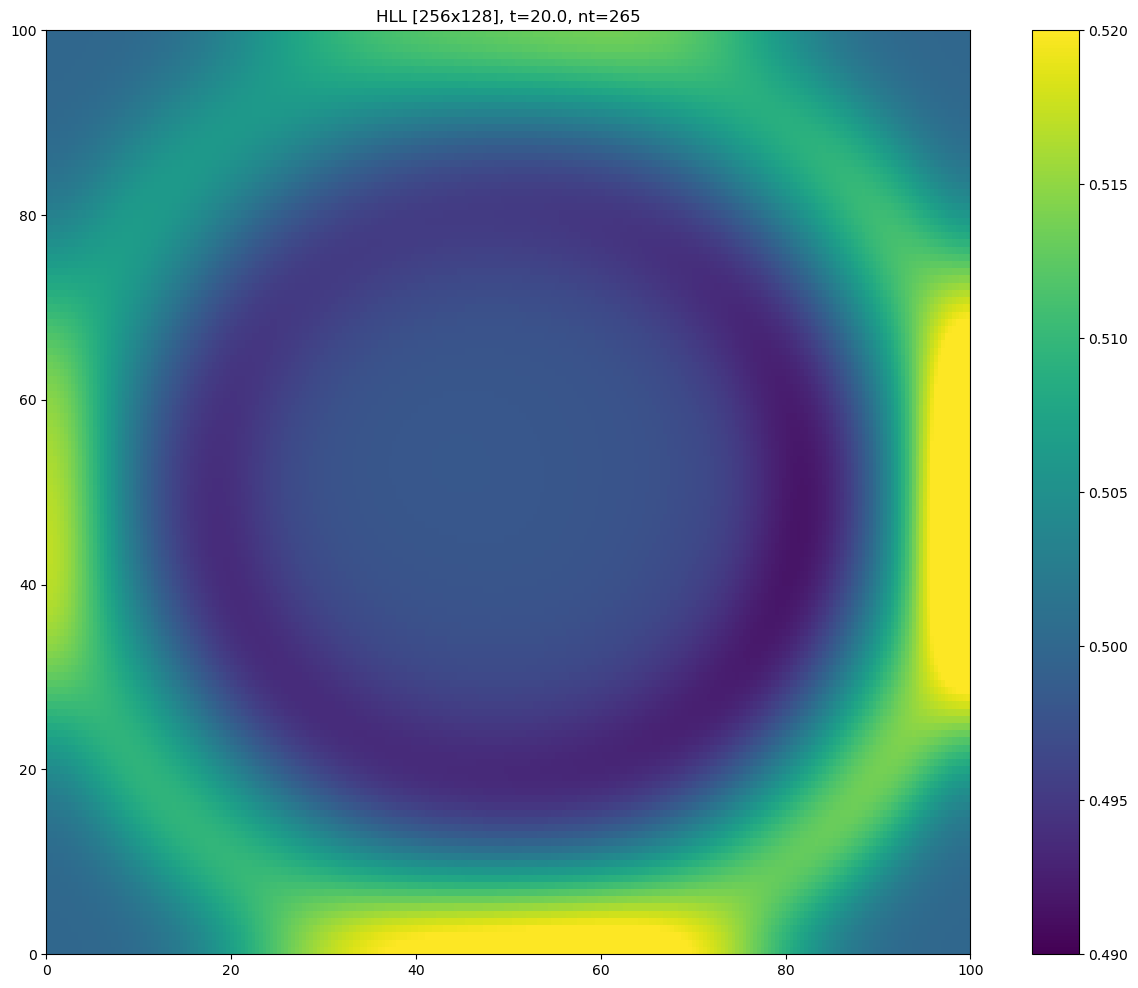

In [8]:
from GPUSimulators.model import HLL

with Timer("construct") as t:
    sim = HLL(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

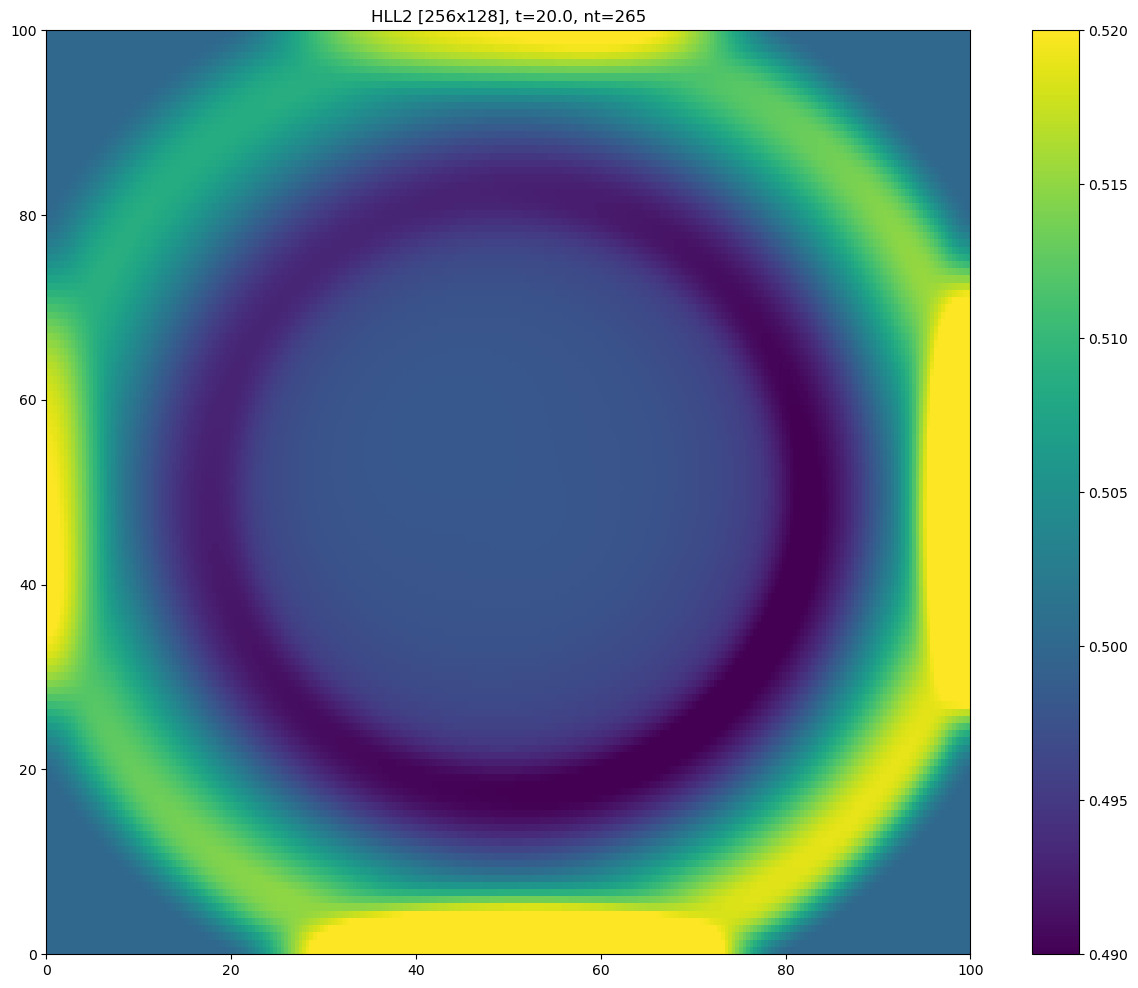

In [9]:
from GPUSimulators.model import HLL2

with Timer("construct") as t:
    sim = HLL2(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

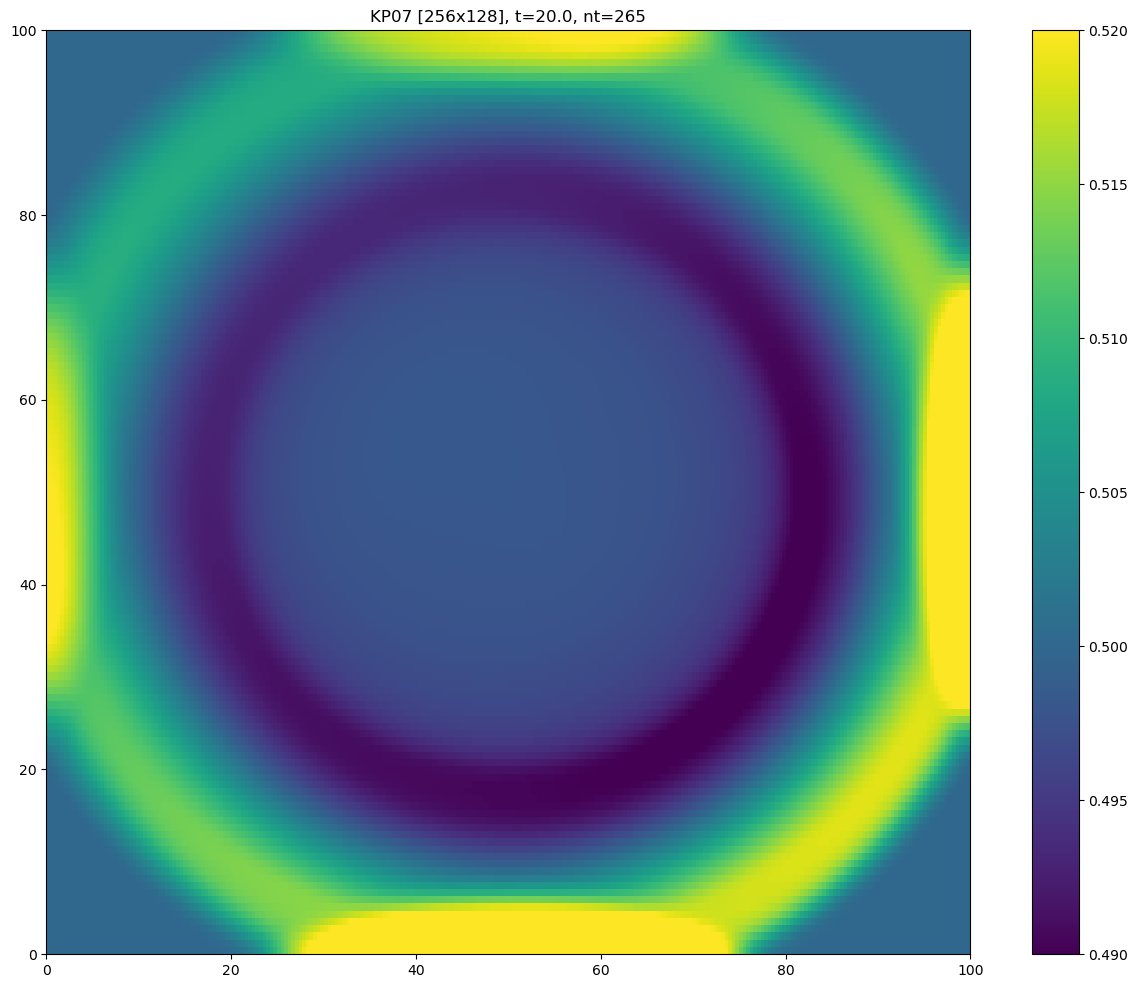

In [10]:
from GPUSimulators.model import KP07

with Timer("construct") as t:
    sim = KP07(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

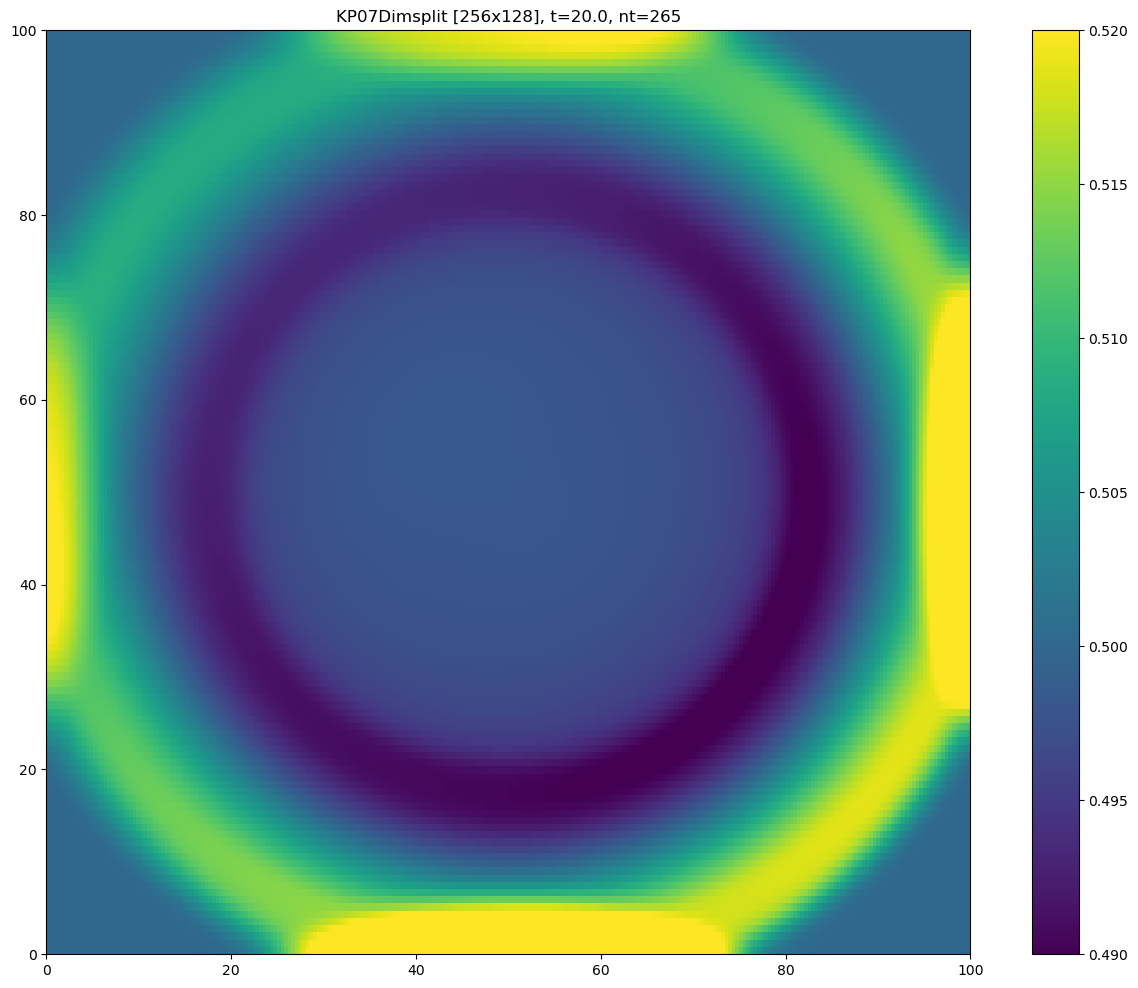

In [11]:
from GPUSimulators.model import KP07Dimsplit

with Timer("construct") as t:
    sim = KP07Dimsplit(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

In [13]:
# from GPUSimulators.model import WAF
#
# with Timer("construct") as t:
#     sim = WAF(**arguments)
#
# with Timer("step") as t:
#     t = sim.simulate(t_end)
#
# with Timer("download") as t:
#     h1, hu1, hv1 = sim.download()
#
# plot(sim)

Running Simulator:   0%|          | 0/20.0 [00:00<?, ?it/s]

: 